# CNN tutorial notebook: MedMNIST classification

This notebook follows the **same numbering** as the CNN recipe card.

We will use a small CNN on a MedMNIST dataset, controlled by

```python
DATASET_FLAG = "bloodmnist"   # try "pneumoniamnist"
```

The notebook is written so the same code can be reused for other MedMNIST classification datasets.

## 1- Load libraries: Basics + PyTorch

We first load the core Python, PyTorch, and visualization libraries.  
We also load **MedMNIST**, which provides the dataset and its metadata.

In [1]:
import sys
import subprocess
import pkgutil

# Install medmnist if needed
if pkgutil.find_loader("medmnist") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

import copy
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

import medmnist
from medmnist import INFO

In [2]:
# Main dataset flag for this notebook
DATASET_FLAG = "bloodmnist"   # try "pneumoniamnist"

# Basic training setup
BATCH_SIZE = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch version:", torch.__version__)
print("medmnist version:", medmnist.__version__)

device: cuda
torch version: 2.3.1
medmnist version: 3.0.2


## 2- Load your grid Dataset $D$

Make sure $D$ is a collection of input-label pairs:

$$
D[i] = (X_i, Y_i)
$$

In this notebook:

- $X_i$ is an image/grid with shape $C_{in} \times H \times W$
- $Y_i$ is a categorical class label
- so this is a **classification** task

In [3]:
# Read metadata from MedMNIST
info = INFO[DATASET_FLAG]
task = info["task"]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_names = list(info["label"].values())
DataClass = getattr(medmnist, info["python_class"])

print(f"dataset flag : {DATASET_FLAG}")
print(f"task         : {task}")
print(f"n_classes    : {n_classes}")
print(f"n_channels   : {n_channels}")
print(f"python class : {info['python_class']}")
print("class names  :", class_names)

dataset flag : bloodmnist
task         : multi-class
n_classes    : 8
n_channels   : 3
python class : BloodMNIST
class names  : ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [4]:
# Simple transform: convert images to tensors in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# MedMNIST already provides train / val / test splits
train_dataset = DataClass(split="train", transform=transform, download=True)
val_dataset   = DataClass(split="val",   transform=transform, download=True)
test_dataset  = DataClass(split="test",  transform=transform, download=True)

print("train:", len(train_dataset))
print("val  :", len(val_dataset))
print("test :", len(test_dataset))

x0, y0 = train_dataset[0]
print("one sample image shape:", tuple(x0.shape))
print("one sample label shape:", np.array(y0).shape)
print("one sample label      :", y0)

Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
Using downloaded and verified file: /home/tiamheydari/.medmnist/bloodmnist.npz
train: 11959
val  : 1712
test : 3421
one sample image shape: (3, 28, 28)
one sample label shape: (1,)
one sample label      : [7]


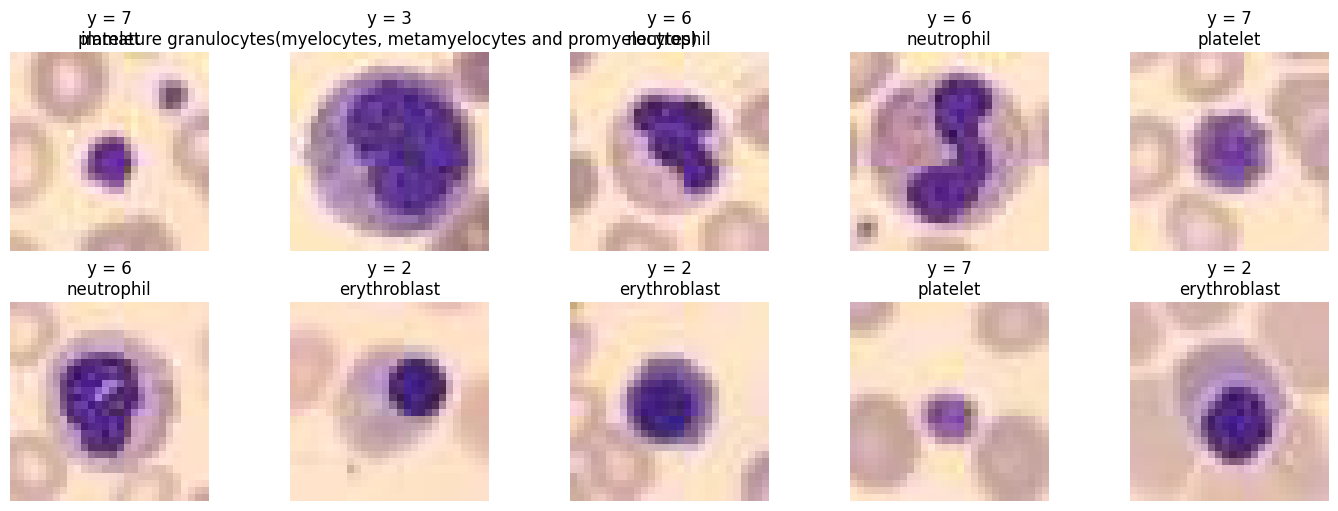

In [5]:
def show_dataset_samples(dataset, class_names, n_show=10):
    fig, axes = plt.subplots(2, math.ceil(n_show / 2), figsize=(14, 5), constrained_layout=True)
    axes = axes.ravel()

    for i in range(n_show):
        x, y = dataset[i]
        y = int(np.array(y).squeeze())

        if x.shape[0] == 1:
            axes[i].imshow(x.squeeze(0), cmap="gray")
        else:
            axes[i].imshow(np.transpose(x.numpy(), (1, 2, 0)))

        axes[i].set_title(f"y = {y}\n{class_names[y]}")
        axes[i].axis("off")

    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.show()

show_dataset_samples(train_dataset, class_names, n_show=10)

## 3- Set up the DataLoader for training / validation / testing

We now wrap the train, validation, and test splits in PyTorch `DataLoader`s so the model can process mini-batches.

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print("batch image shape:", tuple(batch_x.shape))
print("batch label shape:", np.array(batch_y).shape)

batch image shape: (128, 3, 28, 28)
batch label shape: (128, 1)


## 4- Build the CNN neural network as a Module

A CNN learns local filters (kernels) and applies them across the grid.

For this notebook we use a small classification CNN with two conv blocks:

$$
X_i \to [\text{Conv} \to \text{ReLU} \to \text{Pool}]
\to ...
\to [\text{Conv} \to \text{ReLU} \to \text{Pool}]
\to \text{Flatten} \to \text{Linear} \to \hat{Y}_i
$$

Because the final task is classification, the last layer outputs **raw logits** with one value per class.

In [24]:
class SimpleMedMNISTCNN(nn.Module):
    def __init__(self, in_channels: int, n_classes: int, input_hw=(28, 28)):
        super().__init__()

        # --------------------------------------------------
        # Convolutional feature extractor
        # --------------------------------------------------
        # Block 1:
        #   Conv -> ReLU -> MaxPool
        #
        # Input:  [B, in_channels, 28, 28]
        # Conv:   [B, 16, 28, 28]
        # Pool:   [B, 16, 14, 14]
        #
        # Block 2:
        #   Conv -> ReLU -> MaxPool
        #
        # Conv:   [B, 32, 14, 14]
        # Pool:   [B, 32,  7,  7]
        #
        # So this part learns local filters and gradually
        # builds more useful feature maps while reducing
        # spatial size.
        self.features = nn.Sequential(
            # ----- Conv Block 1 -----
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=16,
                kernel_size=3,
                stride=1,
                padding=1,   # keeps height/width the same before pooling
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,    # downsamples 28x28 -> 14x14
            ),

            # ----- Conv Block 2 -----
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,   # keeps 14x14 the same before pooling
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,    # downsamples 14x14 -> 7x7
            ),
        )

        # --------------------------------------------------
        # Find the flattened feature size automatically
        # --------------------------------------------------
        # Instead of calculating it by hand, we pass a dummy
        # tensor through the feature extractor once.
        # This is convenient and avoids shape mistakes.
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, *input_hw)
            dummy_out = self.features(dummy)
            flat_dim = dummy_out.numel()

        # --------------------------------------------------
        # Classification head
        # --------------------------------------------------
        # After the conv blocks, we flatten the feature maps
        # into one vector per image, then use two Linear layers
        # to predict class logits.
        #
        # Output:
        #   logits shape = [B, n_classes]
        #
        # We return raw logits because CrossEntropyLoss expects
        # logits directly.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: [B, in_channels, H, W]

        # Extract convolutional feature maps
        x = self.features(x)

        # Convert features into class logits
        logits = self.classifier(x)

        return logits
        


# Build model from the dataset metadata
sample_x, _ = train_dataset[0]
_, H, W = sample_x.shape

model = SimpleMedMNISTCNN(
    in_channels=n_channels,
    n_classes=n_classes,
    input_hw=(H, W),
).to(device)

print(model)

SimpleMedMNISTCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)


## 5- Define a proper loss function based on $Y_i$

Here $Y_i$ is **categorical**, so we use `CrossEntropyLoss`.

Important note:
- `CrossEntropyLoss` expects **raw logits**
- therefore we do **not** apply softmax inside the model

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("criterion:", criterion)
print("optimizer:", optimizer)

criterion: CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 6- Define the train and test functions

We now define:
- a `train_one_epoch()` function for parameter updates
- an `evaluate()` function for validation / test

For classification, we will track:
- loss
- accuracy

In [26]:
def prepare_targets(y):
    # MedMNIST labels often come with shape [B, 1]
    # CrossEntropyLoss expects class indices with shape [B]
    if isinstance(y, np.ndarray):
        y = torch.from_numpy(y)
    return y.squeeze().long()


def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    correct = (preds == y).sum().item()
    total = y.size(0)
    return correct / total


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = prepare_targets(y).to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return running_loss / n_batches, running_acc / n_batches

## 7- Define training and run the training

We now train the model for several epochs, track train/validation loss and accuracy, and keep the best model based on validation accuracy.

In [27]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
    )

# Load best model
model.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/8 | train loss: 1.4834 | train acc: 0.4470 | val loss: 1.0430 | val acc: 0.6049
Epoch 02/8 | train loss: 0.9173 | train acc: 0.6699 | val loss: 0.8133 | val acc: 0.7070
Epoch 03/8 | train loss: 0.7803 | train acc: 0.7327 | val loss: 0.6744 | val acc: 0.7751
Epoch 04/8 | train loss: 0.6938 | train acc: 0.7634 | val loss: 0.5941 | val acc: 0.8041
Epoch 05/8 | train loss: 0.6025 | train acc: 0.7962 | val loss: 0.5560 | val acc: 0.8112
Epoch 06/8 | train loss: 0.5572 | train acc: 0.8032 | val loss: 0.4881 | val acc: 0.8250
Epoch 07/8 | train loss: 0.5052 | train acc: 0.8234 | val loss: 0.4809 | val acc: 0.8346
Epoch 08/8 | train loss: 0.4866 | train acc: 0.8264 | val loss: 0.4478 | val acc: 0.8324

Best validation accuracy: 0.8346


In [28]:
# Final test evaluation
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")

Test loss: 0.5067
Test acc : 0.8258


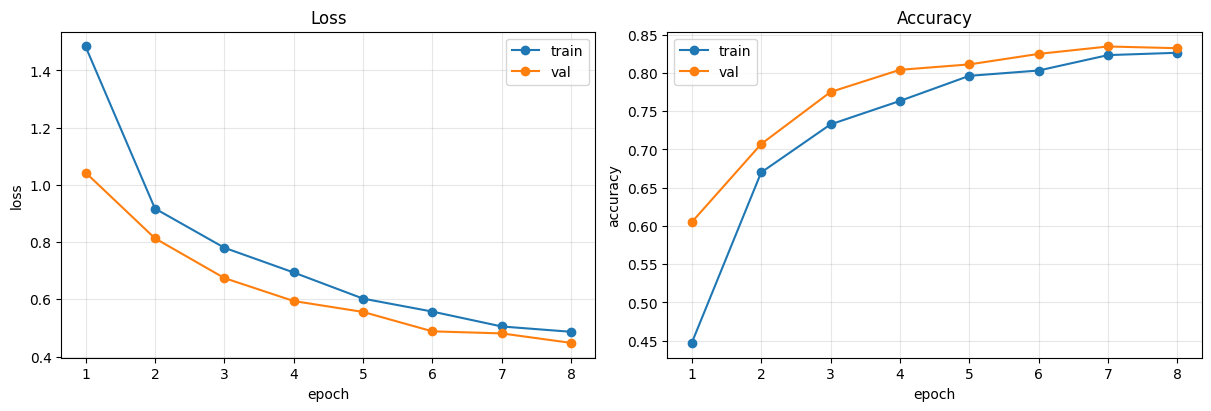

In [29]:
# Plot learning curves
epochs = np.arange(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs, history["val_acc"], marker="o", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

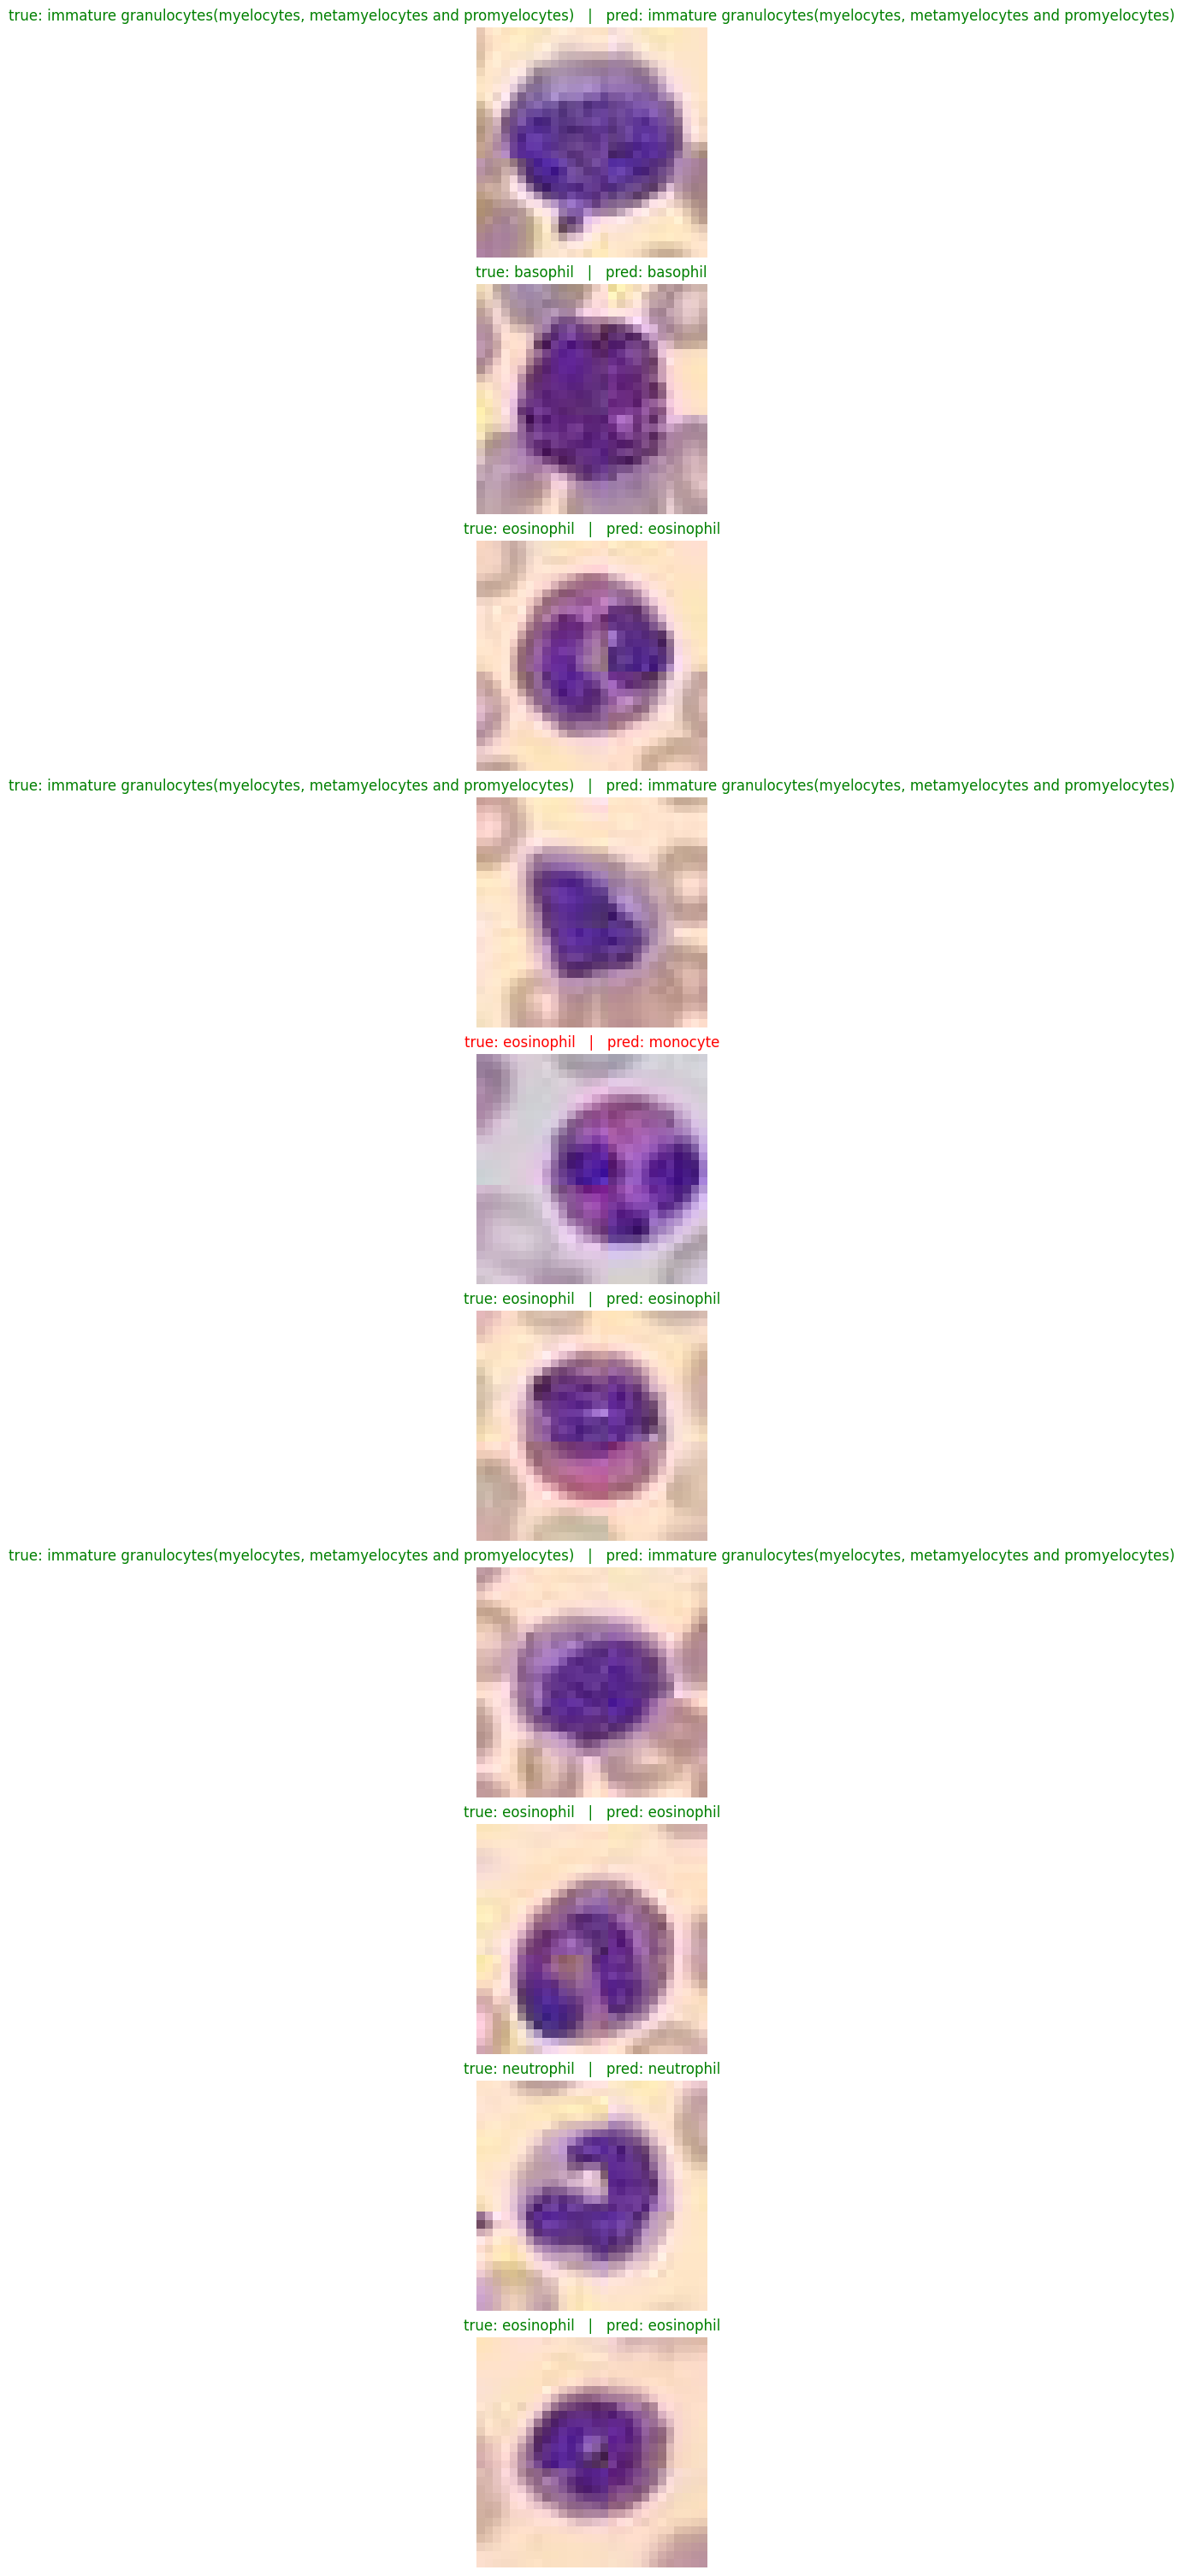

In [31]:
@torch.no_grad()
def show_predictions(model, dataset, class_names, device, n_show=10):
    model.eval()

    # One sample per row
    fig, axes = plt.subplots(n_show, 1, figsize=(5, 3 * n_show), constrained_layout=True)

    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        x, y = dataset[i]
        y_true = int(np.array(y).squeeze())

        logits = model(x.unsqueeze(0).to(device))
        y_pred = int(logits.argmax(dim=1).item())

        if x.shape[0] == 1:
            axes[i].imshow(x.squeeze(0), cmap="gray")
        else:
            axes[i].imshow(np.transpose(x.numpy(), (1, 2, 0)))

        axes[i].set_title(
            f"true: {class_names[y_true]}   |   pred: {class_names[y_pred]}",
            color=("green" if y_true == y_pred else "red"),
            fontsize=12
        )
        axes[i].axis("off")

    plt.show()


show_predictions(model, test_dataset, class_names, device, n_show=10)